# 🤖 Model Training + MLflow Experiment Tracking
## Customer Churn Prediction Project
**Aim:** 4 models train, compare, tune — best model deploy

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sys
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    cross_val_score, RandomizedSearchCV, StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve
)
from sklearn.pipeline import Pipeline as SKPipeline

import xgboost as xgb
import lightgbm as lgb
import mlflow
import mlflow.sklearn

sys.path.append('..')
from src.feature_engineering import engineer_features

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [2]:
# Data Load
X_train_processed = np.load('../data/processed/X_train_processed.npy')
X_test_processed  = np.load('../data/processed/X_test_processed.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

with open('../models/preprocessor.pkl', 'rb') as f:
    preprocessor = pickle.load(f)
with open('../models/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

X_train_orig = pd.read_csv('../data/processed/X_train.csv')
X_test_orig  = pd.read_csv('../data/processed/X_test.csv')

print(f"Train : {X_train_processed.shape}")
print(f"Test  : {X_test_processed.shape}")
print(f"Churn rate — Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")
print("✅ Data loaded!")

Train : (5634, 29)
Test  : (1409, 29)
Churn rate — Train: 0.265 | Test: 0.265
✅ Data loaded!


In [3]:
# Evaluation Function
def evaluate_model(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(
        model, X_tr, y_tr, cv=cv, scoring='roc_auc'
    )

    metrics = {
        'accuracy'         : accuracy_score(y_te, y_pred),
        'precision'        : precision_score(y_te, y_pred),
        'recall'           : recall_score(y_te, y_pred),
        'f1_score'         : f1_score(y_te, y_pred),
        'roc_auc'          : roc_auc_score(y_te, y_proba),
        'cv_roc_auc_mean'  : cv_scores.mean(),
        'cv_roc_auc_std'   : cv_scores.std()
    }

    print(f"\n{'='*50}")
    print(f"📊 {name}")
    print(f"{'='*50}")
    for k, v in metrics.items():
        print(f"  {k:22s}: {v:.4f}")

    return model, metrics, y_pred, y_proba

In [4]:
# Plot Function
def plot_results(y_te, y_pred, y_proba, name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion Matrix
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
        xticklabels=['No Churn', 'Churn'],
        yticklabels=['No Churn', 'Churn'],
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    tn, fp, fn, tp = cm.ravel()
    axes[0].set_title(f'{name}\nConfusion Matrix',
                      fontweight='bold', fontsize=13)
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')
    axes[0].text(
        0.5, -0.12,
        f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
        transform=axes[0].transAxes,
        ha='center', color='gray', fontsize=10
    )

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_te, y_proba)
    auc = roc_auc_score(y_te, y_proba)
    axes[1].plot(fpr, tpr, color='#e74c3c', lw=2,
                 label=f'AUC = {auc:.4f}')
    axes[1].plot([0,1],[0,1], 'k--', alpha=0.4,
                 label='Random')
    axes[1].fill_between(fpr, tpr, alpha=0.08, color='#e74c3c')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{name}\nROC Curve',
                      fontweight='bold', fontsize=13)
    axes[1].legend(loc='lower right')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    safe_name = name.replace(' ', '_')
    plt.savefig(f'../assets/results/{safe_name}_results.png',
                dpi=150, bbox_inches='tight')
    plt.show()

In [5]:
# MLflow Setup
mlflow.set_tracking_uri('file:../mlruns')
mlflow.set_experiment('customer_churn_prediction')
print("✅ MLflow experiment ready!")
print("📁 Logs: mlruns/")

✅ MLflow experiment ready!
📁 Logs: mlruns/


 Model 1: Logistic Regression (Baseline)

2026/03/28 10:20:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



📊 Logistic Regression
  accuracy              : 0.7424
  precision             : 0.5093
  recall                : 0.8021
  f1_score              : 0.6231
  roc_auc               : 0.8456
  cv_roc_auc_mean       : 0.8472
  cv_roc_auc_std        : 0.0114


2026/03/28 10:20:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Logged to MLflow!


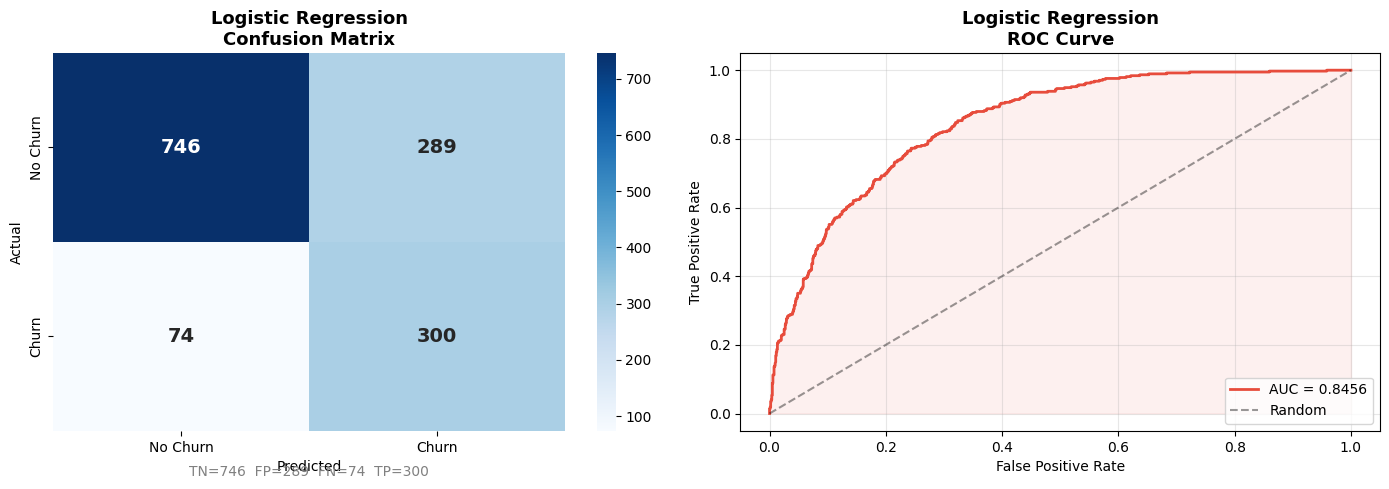

In [6]:
with mlflow.start_run(run_name="Logistic_Regression"):
    lr = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        C=1.0
    )
    lr, lr_m, lr_pred, lr_proba = evaluate_model(
        lr, X_train_processed, X_test_processed,
        y_train, y_test, "Logistic Regression"
    )
    mlflow.log_params({
        'model'       : 'LogisticRegression',
        'C'           : 1.0,
        'class_weight': 'balanced'
    })
    mlflow.log_metrics(lr_m)
    mlflow.sklearn.log_model(lr, "model")
    print("✅ Logged to MLflow!")

plot_results(y_test, lr_pred, lr_proba, "Logistic Regression")

Model 2: Random Forest

2026/03/28 10:20:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



📊 Random Forest
  accuracy              : 0.7800
  precision             : 0.5664
  recall                : 0.7299
  f1_score              : 0.6379
  roc_auc               : 0.8427
  cv_roc_auc_mean       : 0.8430
  cv_roc_auc_std        : 0.0093


2026/03/28 10:20:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Logged to MLflow!


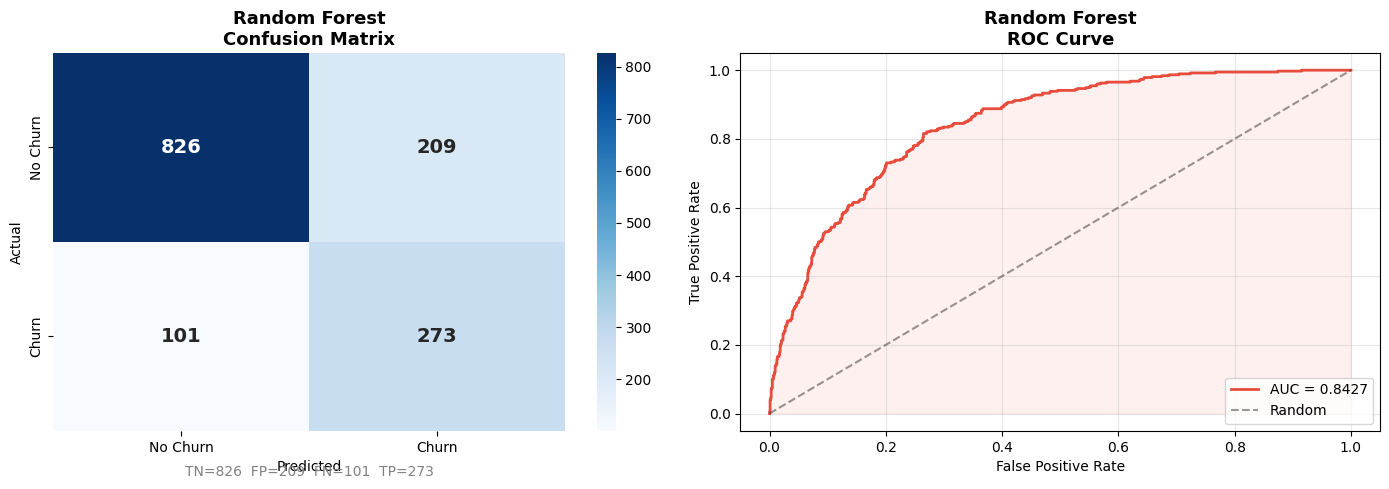

In [7]:
with mlflow.start_run(run_name="Random_Forest"):
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf, rf_m, rf_pred, rf_proba = evaluate_model(
        rf, X_train_processed, X_test_processed,
        y_train, y_test, "Random Forest"
    )
    mlflow.log_params({
        'model'            : 'RandomForest',
        'n_estimators'     : 100,
        'max_depth'        : 10,
        'min_samples_split': 5
    })
    mlflow.log_metrics(rf_m)
    mlflow.sklearn.log_model(rf, "model")
    print("✅ Logged to MLflow!")

plot_results(y_test, rf_pred, rf_proba, "Random Forest")

Model 3: XGBoost

scale_pos_weight: 2.77


2026/03/28 10:21:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



📊 XGBoost
  accuracy              : 0.7644
  precision             : 0.5447
  recall                : 0.6845
  f1_score              : 0.6066
  roc_auc               : 0.8344
  cv_roc_auc_mean       : 0.8282
  cv_roc_auc_std        : 0.0080


2026/03/28 10:21:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Logged to MLflow!


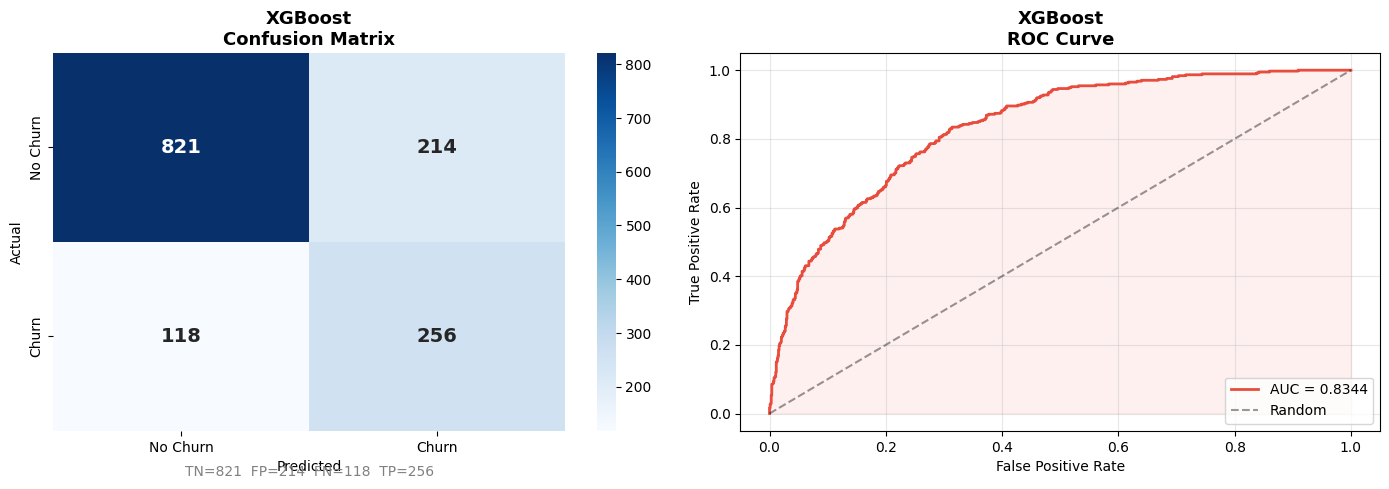

In [8]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = neg / pos
print(f"scale_pos_weight: {scale_pos:.2f}")

with mlflow.start_run(run_name="XGBoost"):
    xgb_m = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        random_state=42,
        eval_metric='auc',
        verbosity=0
    )
    xgb_m, xgb_met, xgb_pred, xgb_proba = evaluate_model(
        xgb_m, X_train_processed, X_test_processed,
        y_train, y_test, "XGBoost"
    )
    mlflow.log_params({
        'model'           : 'XGBoost',
        'n_estimators'    : 200,
        'learning_rate'   : 0.1,
        'scale_pos_weight': round(scale_pos, 2)
    })
    mlflow.log_metrics(xgb_met)
    mlflow.sklearn.log_model(xgb_m, "model")
    print("✅ Logged to MLflow!")

plot_results(y_test, xgb_pred, xgb_proba, "XGBoost")

Model 4: LightGBM

2026/03/28 10:21:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



📊 LightGBM
  accuracy              : 0.7551
  precision             : 0.5264
  recall                : 0.7727
  f1_score              : 0.6262
  roc_auc               : 0.8400
  cv_roc_auc_mean       : 0.8368
  cv_roc_auc_std        : 0.0095


2026/03/28 10:21:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Logged to MLflow!


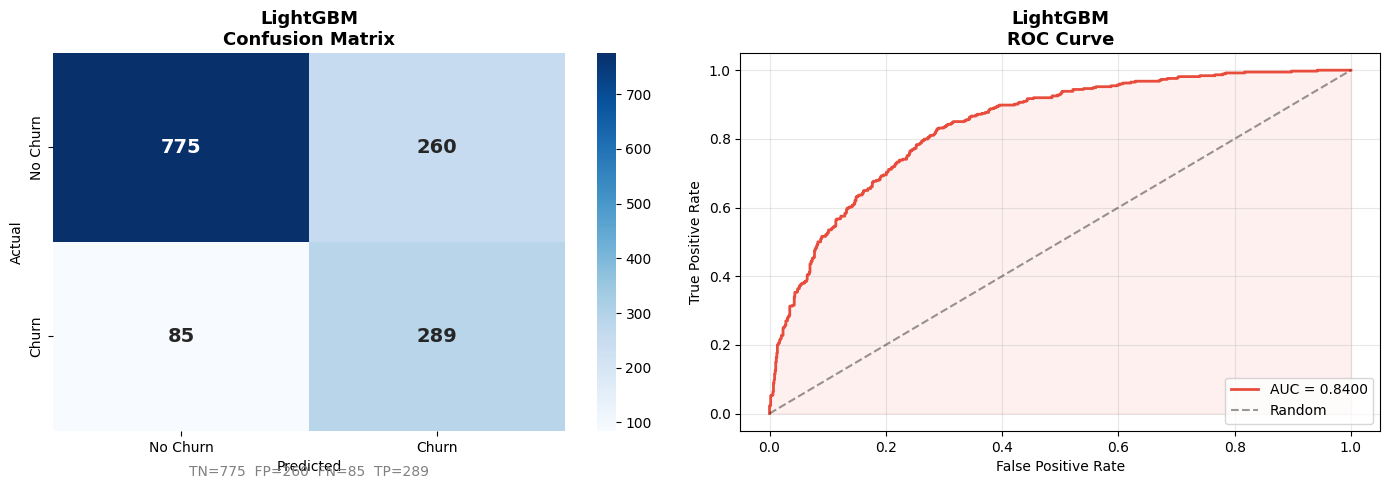

In [9]:
with mlflow.start_run(run_name="LightGBM"):
    lgb_m = lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        class_weight='balanced',
        random_state=42,
        verbosity=-1
    )
    lgb_m, lgb_met, lgb_pred, lgb_proba = evaluate_model(
        lgb_m, X_train_processed, X_test_processed,
        y_train, y_test, "LightGBM"
    )
    mlflow.log_params({
        'model'       : 'LightGBM',
        'n_estimators': 200,
        'num_leaves'  : 31,
        'learning_rate': 0.05
    })
    mlflow.log_metrics(lgb_met)
    mlflow.sklearn.log_model(lgb_m, "model")
    print("✅ Logged to MLflow!")

plot_results(y_test, lgb_pred, lgb_proba, "LightGBM")

Model Comparison

In [10]:
# Comparison Table
results = pd.DataFrame({
    'Model'    : ['Logistic Regression','Random Forest',
                  'XGBoost','LightGBM'],
    'Accuracy' : [lr_m['accuracy'],  rf_m['accuracy'],
                  xgb_met['accuracy'], lgb_met['accuracy']],
    'Precision': [lr_m['precision'], rf_m['precision'],
                  xgb_met['precision'],lgb_met['precision']],
    'Recall'   : [lr_m['recall'],    rf_m['recall'],
                  xgb_met['recall'],  lgb_met['recall']],
    'F1'       : [lr_m['f1_score'],  rf_m['f1_score'],
                  xgb_met['f1_score'],lgb_met['f1_score']],
    'ROC_AUC'  : [lr_m['roc_auc'],   rf_m['roc_auc'],
                  xgb_met['roc_auc'], lgb_met['roc_auc']],
    'CV_AUC'   : [lr_m['cv_roc_auc_mean'],  rf_m['cv_roc_auc_mean'],
                  xgb_met['cv_roc_auc_mean'],lgb_met['cv_roc_auc_mean']]
}).round(4).sort_values('ROC_AUC', ascending=False)

print("\n📊 MODEL COMPARISON")
print(results.to_string(index=False))


📊 MODEL COMPARISON
              Model  Accuracy  Precision  Recall     F1  ROC_AUC  CV_AUC
Logistic Regression    0.7424     0.5093  0.8021 0.6231   0.8456  0.8472
      Random Forest    0.7800     0.5664  0.7299 0.6379   0.8427  0.8430
           LightGBM    0.7551     0.5264  0.7727 0.6262   0.8400  0.8368
            XGBoost    0.7644     0.5447  0.6845 0.6066   0.8344  0.8282


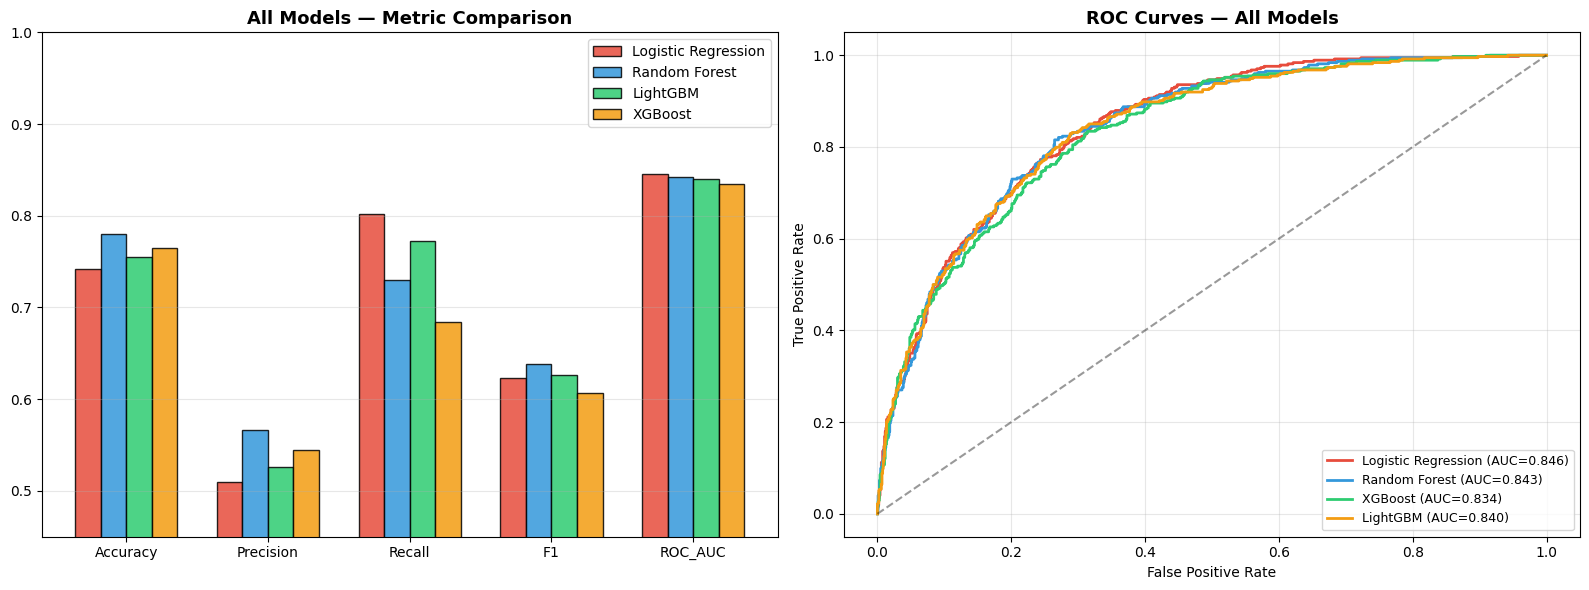

In [ ]:
# Visual Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12']
metrics_list = ['Accuracy','Precision','Recall','F1','ROC_AUC']
x = np.arange(len(metrics_list))
w = 0.18

for i, (_, row) in enumerate(results.iterrows()):
    vals = [row[m] for m in metrics_list]
    axes[0].bar(x + i*w, vals, w,
                label=row['Model'],
                color=colors[i], alpha=0.85,
                edgecolor='black')

axes[0].set_xticks(x + w*1.5)
axes[0].set_xticklabels(metrics_list)
axes[0].set_ylim(0.45, 1.0)
axes[0].set_title('All Models — Metric Comparison',
                  fontweight='bold', fontsize=13)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ROC Curves
all_probas = [lr_proba, rf_proba, xgb_proba, lgb_proba]
all_names  = ['Logistic Regression','Random Forest',
              'XGBoost','LightGBM']

for name, proba, color in zip(all_names, all_probas, colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[1].plot(fpr, tpr, color=color, lw=2,
                 label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models',
                  fontweight='bold', fontsize=13)
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/results/model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

 Hyperparameter Tuning (Best Model)

In [ ]:
# RandomizedSearchCV
print(f"🏆 Best model: {results.iloc[0]['Model']}")
print("Tuning started... (3-5 minutes needed)")

param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [3, 4, 5, 6, 8],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'subsample'        : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9],
    'min_child_weight' : [1, 3, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_xgb = xgb.XGBClassifier(
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

search = RandomizedSearchCV(
    base_xgb, param_dist,
    n_iter=20, cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1, verbose=1
)
search.fit(X_train_processed, y_train)

print(f"\n🎯 Best CV AUC: {search.best_score_:.4f}")
print(f"\nBest Params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

🏆 Best model: Logistic Regression
Tuning শুরু হচ্ছে... (৩-৫ মিনিট লাগবে)
Fitting 5 folds for each of 20 candidates, totalling 100 fits

🎯 Best CV AUC: 0.8481

Best Params:
  subsample: 0.8
  n_estimators: 200
  min_child_weight: 5
  max_depth: 3
  learning_rate: 0.05
  colsample_bytree: 0.7


2026/03/28 10:23:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



📊 XGBoost Tuned
  accuracy              : 0.7452
  precision             : 0.5130
  recall                : 0.7914
  f1_score              : 0.6225
  roc_auc               : 0.8457
  cv_roc_auc_mean       : 0.8475
  cv_roc_auc_std        : 0.0112


2026/03/28 10:23:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Logged to MLflow!


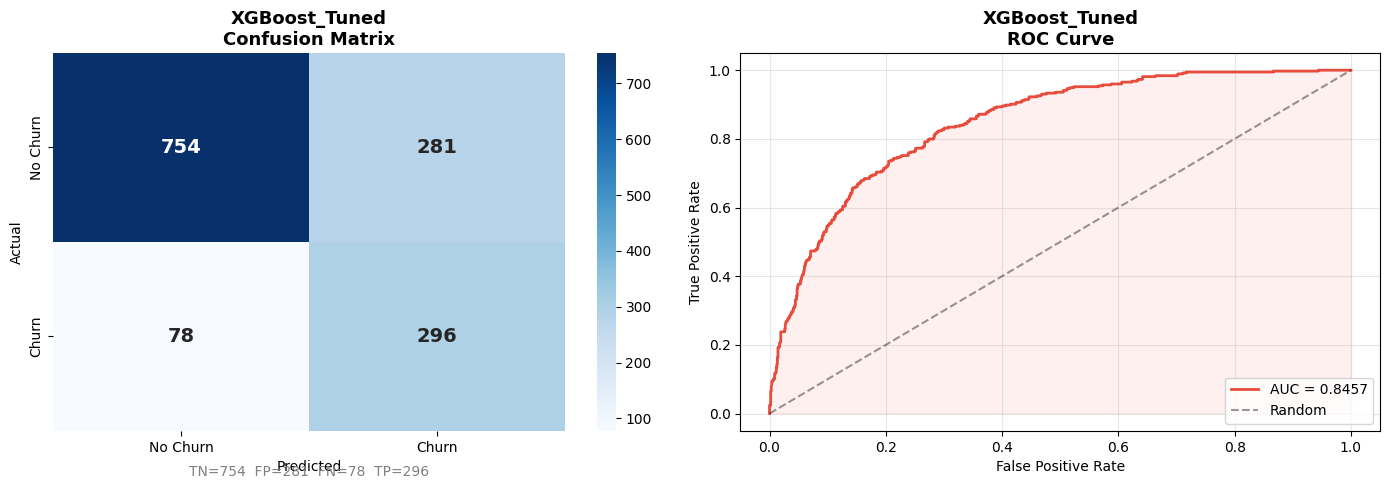

In [12]:
# Tuned Model Evaluate
with mlflow.start_run(run_name="XGBoost_Tuned"):
    best_xgb = search.best_estimator_
    _, tuned_m, tuned_pred, tuned_proba = evaluate_model(
        best_xgb,
        X_train_processed, X_test_processed,
        y_train, y_test, "XGBoost Tuned"
    )
    mlflow.log_params(search.best_params_)
    mlflow.log_metrics(tuned_m)
    mlflow.sklearn.log_model(best_xgb, "model")
    print("✅ Logged to MLflow!")

plot_results(y_test, tuned_pred, tuned_proba, "XGBoost_Tuned")

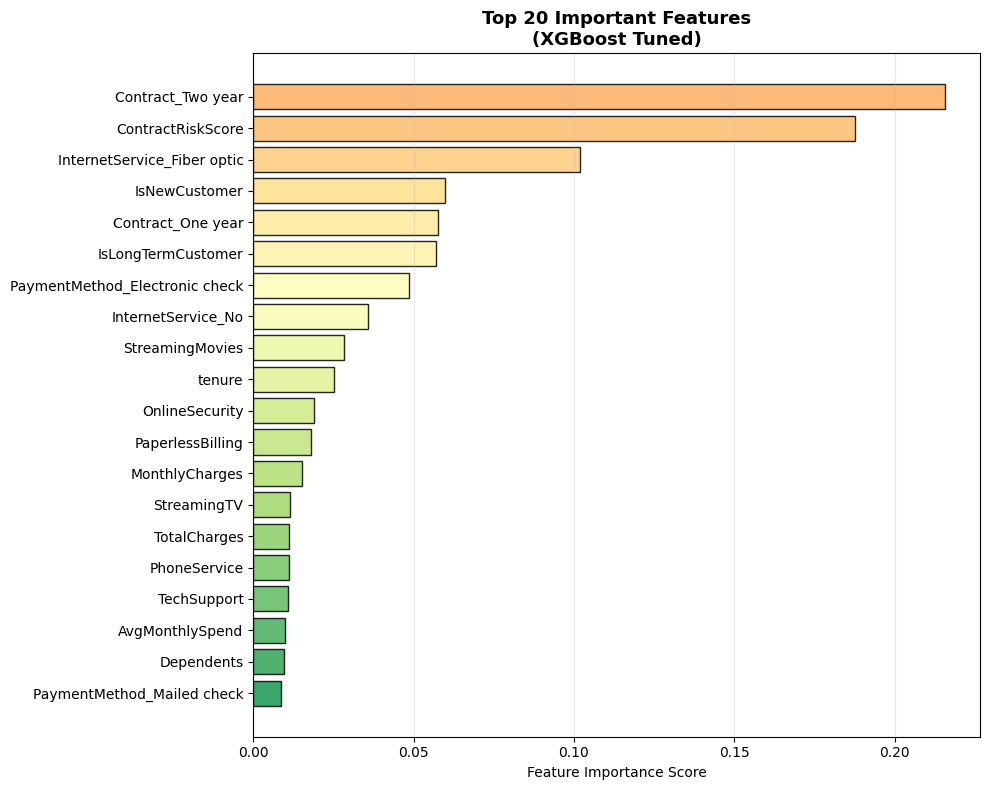


🔍 Top 10 Features:
                       Feature  Importance
             Contract_Two year    0.215787
             ContractRiskScore    0.187516
   InternetService_Fiber optic    0.101966
                 IsNewCustomer    0.059679
             Contract_One year    0.057713
            IsLongTermCustomer    0.056874
PaymentMethod_Electronic check    0.048596
            InternetService_No    0.035878
               StreamingMovies    0.028338
                        tenure    0.025217


In [13]:
# Feature Importance
importances = best_xgb.feature_importances_
feat_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
colors_bar = plt.cm.RdYlGn(
    np.linspace(0.3, 0.9, len(feat_df))
)[::-1]
plt.barh(feat_df['Feature'][::-1],
         feat_df['Importance'][::-1],
         color=colors_bar, edgecolor='black', alpha=0.85)
plt.xlabel('Feature Importance Score')
plt.title('Top 20 Important Features\n(XGBoost Tuned)',
          fontweight='bold', fontsize=13)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../assets/results/feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 Top 10 Features:")
print(feat_df.head(10).to_string(index=False))

In [ ]:
# Full Pipeline Save
full_pipeline = SKPipeline([
    ('preprocessor', preprocessor),
    ('model', best_xgb)
])
full_pipeline.fit(X_train_orig, y_train)

with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

with open('../models/full_pipeline.pkl', 'wb') as f:
    pickle.dump(full_pipeline, f)

print("✅ Models saved!")
print("  📁 models/best_model.pkl")
print("  📁 models/full_pipeline.pkl  ← App use")

✅ Models saved!
  📁 models/best_model.pkl
  📁 models/full_pipeline.pkl  ← App এ এটা use হবে


In [ ]:
# Final Summary
print("="*55)
print("🎉MODELING DONE!")
print("="*55)
print(f"\n📊 Final Results:")
print(results[['Model','F1','ROC_AUC','CV_AUC']].to_string(index=False))
print(f"\n🏆 Winner: XGBoost Tuned")
print(f"   ROC-AUC : {tuned_m['roc_auc']:.4f}")
print(f"   F1 Score: {tuned_m['f1_score']:.4f}")
print(f"\n✅ Saved: models/full_pipeline.pkl")

🎉 DAY 1-3 COMPLETE — MODELING DONE!

📊 Final Results:
              Model     F1  ROC_AUC  CV_AUC
Logistic Regression 0.6231   0.8456  0.8472
      Random Forest 0.6379   0.8427  0.8430
           LightGBM 0.6262   0.8400  0.8368
            XGBoost 0.6066   0.8344  0.8282

🏆 Winner: XGBoost Tuned
   ROC-AUC : 0.8457
   F1 Score: 0.6225

✅ Saved: models/full_pipeline.pkl

➡️  Next: streamlit run app/streamlit_app.py
